# Comparación de precios y promociones — DIA vs Carrefour

## Alcance de este notebook

Este proyecto analiza y compara los precios de productos entre los supermercados **DIA** y **Carrefour**, utilizando los datasets de productos correspondientes a julio de 2026 del Sistema SEPA.

Los datasets combinados superan los 7,6 millones de observaciones, lo que permite trabajar con un volumen significativo de datos reales.

En esta primera etapa se realiza:

- carga e integración de los datasets;
- identificación de productos comunes mediante `id_producto`;
- limpieza de registros no correspondientes a productos;
- normalización de variables de precio;
- construcción de un precio efectivo para comparar precios observados;
- análisis de la dispersión de precios entre sucursales;
- análisis mediante rango porcentual y coeficiente de variación;
- análisis de la presencia y profundidad de promociones;
- revisión de casos extremos para determinar si las diferencias son puntuales o generalizadas.

> **Unidad de análisis:** para la comparación de precios, una observación corresponde a un **producto en una sucursal**. Un mismo `id_producto` puede aparecer en múltiples sucursales, lo que permite analizar la variabilidad del precio entre puntos de venta.


## Preguntas que guían el análisis de esta etapa

1. ¿Cuántos productos pueden compararse directamente entre ambas cadenas?
2. ¿Qué nivel de dispersión presentan sus precios entre sucursales?
3. ¿Las diferencias de precio son puntuales o se observan de forma generalizada?
4. ¿La dispersión observada puede atribuirse a promociones o también a diferencias en el precio de lista?
5. ¿Qué diferencias existen entre DIA y Carrefour en la frecuencia y profundidad de sus promociones?

## 1. Carga de los datasets

Los archivos originales están separados por `|`. Se cargan inicialmente como texto para evitar problemas de interpretación de tipos en columnas que contienen identificadores, códigos y valores heterogéneos.

Los identificadores se mantienen como texto para preservar su formato original, incluidos posibles ceros a la izquierda.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargamos los datasets como texto para conservar el formato original de
# identificadores y evitar conversiones automáticas de tipos.
productos_dia = pd.read_csv(
    'productos_dia.csv',
    delimiter='|',
    encoding='UTF-8',
    dtype=str,
    low_memory=False
)

productos_carrefour = pd.read_csv(
    'productos_carrefour.csv',
    delimiter='|',
    encoding='UTF-8',
    dtype=str,
    low_memory=False
)

In [57]:
# Comprobamos las dimensiones iniciales de ambos datasets.
print("Dimensiones de productos_dia:", productos_dia.shape)
print("Dimensiones de productos_carrefour:", productos_carrefour.shape)

Dimensiones de productos_dia: (4199778, 17)
Dimensiones de productos_carrefour: (3481529, 17)


### Unidad de observación

En estos datasets, una fila representa una observación de un **producto en una sucursal**. Por eso, a lo largo del análisis se distingue entre:

- **observaciones:** filas del dataset;
- **productos:** valores únicos de `id_producto`;
- **sucursales:** valores únicos de `id_sucursal`.

Esta distinción es importante porque un mismo producto puede aparecer en múltiples sucursales.

## 2. Integración: identificación de productos comunes

La comparación directa entre cadenas se realiza mediante `id_producto`.

Un producto se considera comparable cuando su `id_producto` aparece en ambos datasets. Este criterio evita depender de la similitud textual de las descripciones, que pueden variar entre cadenas aunque correspondan al mismo producto.

In [58]:
# Identificamos los IDs de productos presentes en ambas cadenas.
ids_comunes = set(productos_dia['id_producto']).intersection(
    set(productos_carrefour['id_producto'])
)

print("Número de IDs comunes:", len(ids_comunes))
print("Primeros 10 IDs comunes:", list(ids_comunes)[:10])

Número de IDs comunes: 2647
Primeros 10 IDs comunes: ['7790580060602', '7791293022567', '7790250022053', '7798114470057', '7509552928853', '7793147570743', '7891024034897', '7790040143517', '7791866001364', '7792180142955']


In [59]:
# Conservamos las observaciones correspondientes a los productos comunes.
productos_dia_comunes = productos_dia[
    productos_dia['id_producto'].isin(ids_comunes)
].copy()

productos_carrefour_comunes = productos_carrefour[
    productos_carrefour['id_producto'].isin(ids_comunes)
].copy()

print("Observaciones DIA con productos comunes:", productos_dia_comunes.shape)
print("Observaciones Carrefour con productos comunes:", productos_carrefour_comunes.shape)

Observaciones DIA con productos comunes: (2559486, 17)
Observaciones Carrefour con productos comunes: (958576, 17)


### Control inicial de los registros comunes

Se inspeccionan algunos registros para verificar que el criterio de matching funciona.

In [60]:
print("Primeras 5 filas de productos_dia_comunes:")
display(productos_dia_comunes.head(5))

print("Últimas 5 filas de productos_dia_comunes:")
display(productos_dia_comunes.tail(5))

print("Primeras 10 filas de productos_carrefour_comunes:")
display(productos_carrefour_comunes.head(10))

print("Últimas 10 filas de productos_carrefour_comunes:")
display(productos_carrefour_comunes.tail(10))

Primeras 5 filas de productos_dia_comunes:


,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2
3,15,1,1,0000040084107,1,HUEVO DE CHOCOLATE,20.00,GR,KINDE,2785.00,139250.00,1.00,KG,NaN,NaN,NaN,NaN
4,15,1,1,0000042277057,1,CREM FACIAL CUID NUT,100.00,ML,NIVEA,6455.00,64550.00,1.00,LT,NaN,NaN,NaN,NaN
5,15,1,1,0000075079437,1,ANTITRANS CREM WOMEN,58.00,GR,DOVE,18459.00,318258.62,1.00,KG,12750.00,31% de descuento. Precio Promocional Exclusivo...,NaN,NaN
6,15,1,1,0000075082734,1,ANTITRANS ORIG BARRA,50.00,GR,DOVE,8019.00,160380.00,1.00,KG,NaN,NaN,NaN,NaN
7,15,1,1,0000075083694,1,DEO BLUE LAVEN BARRA,58.00,GR,AXE,8699.00,149982.76,1.00,KG,NaN,NaN,NaN,NaN


Últimas 5 filas de productos_dia_comunes:


,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2
4199320,15,1,90000,8445291738775,1,CAFE GOLD,95.00,GR,NESCA,15545.00,163631.58,1.00,KG,NaN,NaN,NaN,NaN
4199321,15,1,90000,8445292738200,1,CAFE NESCAFE SUAVE,160.00,GR,DOLCA,12530.00,78312.50,1.00,KG,NaN,NaN,NaN,NaN
4199775,15,1,90000,9002490288341,1,ENERG POMELO ROS,250.00,ML,REDBU,3439.00,13756.00,1.00,LT,NaN,NaN,2751.20,20% de descuento. 20% REDBULL - Vigencia: Desd...
4199776,15,1,90000,9786313034635,1,JUEGA Y COLOREA AFA,1.00,UD,VERTI,5490.00,5490.00,1.00,UD,NaN,NaN,NaN,NaN
4199777,Última actualización: 2026-07-03T04:05:37-03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Primeras 10 filas de productos_carrefour_comunes:


,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2
2,10,3,873,7791293047102,1,SHAMPOO RECONSTRUCCION COMPLETA DOVE X 400 CC,1,UNI,DOVE,9889.00,24722.50,400,CM3,NaN,NaN,NaN,NaN
7,10,4,709,7791337010598,1,POSTRE CHOCOLATE DANETTE PACK 2 X 95 GRS,1,UNI,DANETTE,4735.00,2492.11,190,GRS,NaN,NaN,NaN,NaN
10,10,2,120,7790040173200,1,GALLETITAS KESITAS ESTUCHE X 125 GRS,1,UNI,KESITAS,2245.00,17960.00,125,GRM,NaN,NaN,NaN,NaN
11,10,1,123,7791564136535,1,QUESO AZUL BAVARIA TROZADO X 125 GRS,1,UNI,BAVARIA,6470.00,5176.00,125,GRS,4390.00,Promo A valida desde el 30/06/2026 hasta 06/07...,NaN,NaN
16,10,3,462,7790639003444,1,GASEOSA TONICA CLASSIC CUNNINGTON X 2.25 LT,1,UNI,CUNNINGTON,2829.00,1257.33,2250,CM3,NaN,NaN,NaN,NaN
20,10,3,557,7791813420385,1,GASEOSA POMELO REGULAR PASO DE LOS TOROS PET X...,1,UNI,PASO DE LOS TOROS,1959.00,3918.00,500,CM3,NaN,NaN,NaN,NaN
26,10,3,767,7790132009158,1,DESTAPACANERIAS LIQUIDO PLOMERO X 1 L,1,UNI,PLOMERO,8969.00,8969.00,1000,CM3,NaN,NaN,NaN,NaN
27,10,3,812,0000077907943,1,CARAMELO MASTICABLE TUTTI FRUTTI LENGUETAZO X ...,1,UNI,LENGUETAZO,464.00,35692.31,13,GRM,NaN,NaN,NaN,NaN
28,10,3,557,7790580132170,1,MERMELADA DAMASCO ARCOR X 454 GRS,1,UNI,ARCOR,3189.00,7024.23,454,GRM,NaN,NaN,NaN,NaN
29,10,4,67,7790895640018,1,ISOTONICA MANZANA POWERADE PET X 500 CC,1,UNI,POWERADE,2290.00,4580.00,500,CM3,NaN,NaN,NaN,NaN


Últimas 10 filas de productos_carrefour_comunes:


,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2
3481493,10,2,176,7790580138721,1,POLENTA INSTANTAN PRESTOPRONTA BOLSA X 730 GRS,1,UNI,PRESTO PRONTA,2309.00,3163.01,730,GRM,NaN,NaN,NaN,NaN
3481504,10,3,796,7790070562074,1,PREMEZCLA CHIPA FORTIFICADA LUCCHETTI X 400 GRS,1,UNI,LUCCHETTI,6170.00,15425.00,400,GRM,NaN,NaN,NaN,NaN
3481505,10,3,222,7790040143364,1,GALLETITAS SURTIDO DIVERSION BOLSA X 400 GRS,1,UNI,DIVERSION,2720.00,6800.00,400,GRM,NaN,NaN,NaN,NaN
3481506,10,3,748,7795323775508,1,LECHE FLUIDA INF ET2 LA SERENISIMA BABY X 200 CC,1,UNI,LA SERENISIMA BABY,1969.00,9845.00,200,CM3,NaN,NaN,NaN,NaN
3481510,10,3,526,7794000007109,1,MAYONESA LIVIANA HELLMANNS DOY PACK X 475 GRS,1,UNI,HELLMANNS,3089.00,6503.16,475,GRM,NaN,NaN,NaN,NaN
3481511,10,2,135,7791451080040,1,DULCE DE MEMBRILLO ESNAOLA X 500 GRS,1,UNI,ESNAOLA,5210.00,10420.00,500,GRM,NaN,NaN,NaN,NaN
3481516,10,3,371,7791813888376,1,GASEOSA COLA REGULAR PEPSI N LATA X 354 CC,1,UNI,PEPSI,2205.00,6228.81,354,CM3,NaN,NaN,NaN,NaN
3481521,10,3,684,7792180140708,1,HARINA LEUDANTE C VIT DPUREZA X 1 KG,1,UNI,PUREZA,1959.00,1959.00,1000,GRM,NaN,NaN,NaN,NaN
3481527,10,3,441,7794529041608,1,TOSTADAS GRUESAS CLASICAS TOSTI X 200 GRS,1,UNI,TOSTI,2039.00,10195.00,200,GRM,NaN,NaN,NaN,NaN
3481528,Ultima actualización: 2026-07-03T08:58:29-03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Los archivos incluyen una fila final de metadatos correspondiente a la leyenda de actualización del archivo SEPA. Esta fila no representa un producto y se identifica porque no contiene `id_producto`.

Se elimina antes de continuar con las transformaciones para que el resto del pipeline trabaje únicamente con observaciones válidas.

In [61]:
# Eliminamos registros que no corresponden a productos.
productos_dia_comunes = productos_dia_comunes.dropna(
    subset=['id_producto']
).copy()

productos_carrefour_comunes = productos_carrefour_comunes.dropna(
    subset=['id_producto']
).copy()

print("Observaciones válidas DIA:", productos_dia_comunes.shape)
print("Observaciones válidas Carrefour:", productos_carrefour_comunes.shape)
print("Productos únicos comunes:", productos_dia_comunes['id_producto'].nunique())

Observaciones válidas DIA: (2559485, 17)
Observaciones válidas Carrefour: (958575, 17)
Productos únicos comunes: 2646


### Verificación de un producto común

Se muestra un producto presente en ambas cadenas para comprobar visualmente que el mismo `id_producto` puede presentar descripciones comerciales diferentes.

In [62]:
# Inspeccionamos un producto de cada cadena para verificar la consistencia de los datos.
ejemplo_id = list(ids_comunes)[11]

print("Producto en DIA:")
display(productos_dia_comunes[
    productos_dia_comunes['id_producto'] == ejemplo_id
])

print("Producto en Carrefour:")
display(productos_carrefour_comunes[
    productos_carrefour_comunes['id_producto'] == ejemplo_id
])

Producto en DIA:


,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2
692,15,1,1,7790045000624,1,CEREALES AZUCARADOS,500.00,GR,SKARC,4430.00,8860.00,1.00,KG,NaN,NaN,NaN,NaN
4999,15,1,3,7790045000624,1,CEREALES AZUCARADOS,500.00,GR,SKARC,4430.00,8860.00,1.00,KG,NaN,NaN,NaN,NaN
9306,15,1,4,7790045000624,1,CEREALES AZUCARADOS,500.00,GR,SKARC,4430.00,8860.00,1.00,KG,NaN,NaN,NaN,NaN
13613,15,1,5,7790045000624,1,CEREALES AZUCARADOS,500.00,GR,SKARC,4430.00,8860.00,1.00,KG,NaN,NaN,NaN,NaN
17920,15,1,6,7790045000624,1,CEREALES AZUCARADOS,500.00,GR,SKARC,4430.00,8860.00,1.00,KG,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4176722,15,1,8013,7790045000624,1,CEREALES AZUCARADOS,500.00,GR,SKARC,4685.00,9370.00,1.00,KG,NaN,NaN,NaN,NaN
4181038,15,1,8014,7790045000624,1,CEREALES AZUCARADOS,500.00,GR,SKARC,4840.00,9680.00,1.00,KG,NaN,NaN,NaN,NaN
4185353,15,1,8016,7790045000624,1,CEREALES AZUCARADOS,500.00,GR,SKARC,4685.00,9370.00,1.00,KG,NaN,NaN,NaN,NaN
4189663,15,1,8017,7790045000624,1,CEREALES AZUCARADOS,500.00,GR,SKARC,4840.00,9680.00,1.00,KG,NaN,NaN,NaN,NaN


Producto en Carrefour:


,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2
3932,10,3,476,7790045000624,1,COPOS DE MAIZ AZUCARADOS SKARCHITOS X 500 GRS,1,UNI,SKARCHITOS,4559.00,9118.00,500,GRM,NaN,NaN,NaN,NaN
18587,10,3,688,7790045000624,1,COPOS DE MAIZ AZUCARADOS SKARCHITOS X 500 GRS,1,UNI,SKARCHITOS,4559.00,9118.00,500,GRM,NaN,NaN,NaN,NaN
20912,10,1,204,7790045000624,1,COPOS DE MAIZ AZUCARADOS SKARCHITOS X 500 GRS,1,UNI,SKARCHITOS,3499.00,6998.00,500,GRM,NaN,NaN,NaN,NaN
21816,10,2,184,7790045000624,1,COPOS DE MAIZ AZUCARADOS SKARCHITOS X 500 GRS,1,UNI,SKARCHITOS,3499.00,6998.00,500,GRM,NaN,NaN,NaN,NaN
25319,10,3,245,7790045000624,1,COPOS DE MAIZ AZUCARADOS SKARCHITOS X 500 GRS,1,UNI,SKARCHITOS,4559.00,9118.00,500,GRM,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3446673,10,3,608,7790045000624,1,COPOS DE MAIZ AZUCARADOS SKARCHITOS X 500 GRS,1,UNI,SKARCHITOS,4559.00,9118.00,500,GRM,NaN,NaN,NaN,NaN
3447179,10,3,368,7790045000624,1,COPOS DE MAIZ AZUCARADOS SKARCHITOS X 500 GRS,1,UNI,SKARCHITOS,4649.00,9298.00,500,GRM,NaN,NaN,NaN,NaN
3453305,10,3,572,7790045000624,1,COPOS DE MAIZ AZUCARADOS SKARCHITOS X 500 GRS,1,UNI,SKARCHITOS,4559.00,9118.00,500,GRM,NaN,NaN,NaN,NaN
3459311,10,3,854,7790045000624,1,COPOS DE MAIZ AZUCARADOS SKARCHITOS X 500 GRS,1,UNI,SKARCHITOS,4559.00,9118.00,500,GRM,NaN,NaN,NaN,NaN


## 3. Calidad de datos

Antes de calcular estadísticas se verifican dos aspectos relevantes:

1. valores nulos en las variables de precio;
2. posibles duplicados para la combinación `id_producto` + `id_sucursal`.

La segunda comprobación permite validar la unidad de observación utilizada posteriormente para comparar precios entre sucursales.

In [63]:
# Comprobamos duplicados en la combinación producto-sucursal.
print(
    "Duplicados producto-sucursal en DIA:",
    productos_dia_comunes.duplicated(
        subset=['id_producto', 'id_sucursal']
    ).sum()
)

print(
    "Duplicados producto-sucursal en Carrefour:",
    productos_carrefour_comunes.duplicated(
        subset=['id_producto', 'id_sucursal']
    ).sum()
)

print("\nNulos en variables de precio — DIA:")
display(
    productos_dia_comunes[
        [
            'productos_precio_lista',
            'productos_precio_unitario_promo1',
            'productos_precio_unitario_promo2'
        ]
    ].isna().sum()
)

print("\nNulos en variables de precio — Carrefour:")
display(
    productos_carrefour_comunes[
        [
            'productos_precio_lista',
            'productos_precio_unitario_promo1',
            'productos_precio_unitario_promo2'
        ]
    ].isna().sum()
)

Duplicados producto-sucursal en DIA: 0
Duplicados producto-sucursal en Carrefour: 0

Nulos en variables de precio — DIA:


productos_precio_lista                    0
productos_precio_unitario_promo1    2291882
productos_precio_unitario_promo2    2156724
dtype: int64


Nulos en variables de precio — Carrefour:


productos_precio_lista                   0
productos_precio_unitario_promo1    935035
productos_precio_unitario_promo2    958575
dtype: int64

### Presencia de promo1 y promo2 antes de construir el precio efectivo

Antes de calcular `precio_efectivo`, cuantificamos cuántos registros tienen cada tipo de promoción, a partir de los nulos ya identificados arriba.

Esto permite anticipar, antes de operar sobre los precios, si ambas cadenas utilizan los dos canales de promoción de la misma manera.

In [64]:
total_dia = productos_dia_comunes.shape[0]
total_carre = productos_carrefour_comunes.shape[0]

con_promo1_dia = total_dia - productos_dia_comunes['productos_precio_unitario_promo1'].isna().sum()
con_promo2_dia = total_dia - productos_dia_comunes['productos_precio_unitario_promo2'].isna().sum()
con_promo1_carre = total_carre - productos_carrefour_comunes['productos_precio_unitario_promo1'].isna().sum()
con_promo2_carre = total_carre - productos_carrefour_comunes['productos_precio_unitario_promo2'].isna().sum()

print(f"DIA — registros con promo1: {con_promo1_dia} ({con_promo1_dia/total_dia:.1%})")
print(f"DIA — registros con promo2: {con_promo2_dia} ({con_promo2_dia/total_dia:.1%})")
print(f"\nCarrefour — registros con promo1: {con_promo1_carre} ({con_promo1_carre/total_carre:.1%})")
print(f"Carrefour — registros con promo2: {con_promo2_carre} ({con_promo2_carre/total_carre:.1%})")

DIA — registros con promo1: 267603 (10.5%)
DIA — registros con promo2: 402761 (15.7%)

Carrefour — registros con promo1: 23540 (2.5%)
Carrefour — registros con promo2: 0 (0.0%)


DIA utiliza ambos canales de promoción: 10,5% de sus registros tienen `promo1` (alcance general) y 15,7% tienen `promo2` (condicionada/especial). Carrefour, en cambio, no registra un solo caso de `promo2` dentro del universo de productos comunes analizados, por lo que las promociones registradas en este subconjunto corresponden a `promo1`.

Esta asimetría es relevante para lo que sigue: como `promo2` no se incorpora al precio efectivo general (ver sección 4), parte de la actividad promocional de DIA no impacta directamente en las métricas de dispersión y profundidad de descuento calculadas más adelante. Por eso, cuando comparemos frecuencia de promociones entre cadenas, distinguiremos entre la cifra combinada (`promo1` + `promo2`) y la cifra de `promo1` solamente, que es la comparación equivalente entre ambas cadenas.

## 4. Construcción de variables de precio

Para comparar precios se distinguen dos conceptos:

- **Precio efectivo general:** menor valor disponible entre el precio de lista y `promo1`.
- **`promo2`:** se conserva como una variable separada, ya que corresponde a una promoción condicionada/especial según la definición utilizada en este dataset.

De esta manera, el análisis de descuentos generales no mezcla automáticamente promociones que pueden estar sujetas a condiciones particulares.

El mismo criterio se aplica a ambas cadenas.

In [65]:
# Convertimos las columnas de precios a valores numéricos.
# Los valores no disponibles se convierten en NaN.
columnas_precio = [
    'productos_precio_lista',
    'productos_precio_unitario_promo1'
]

for columna in columnas_precio:
    productos_dia_comunes[columna] = pd.to_numeric(
        productos_dia_comunes[columna],
        errors='coerce'
    )
    productos_carrefour_comunes[columna] = pd.to_numeric(
        productos_carrefour_comunes[columna],
        errors='coerce'
    )

# promo2 se conserva separadamente y no se incorpora al precio efectivo general.
productos_dia_comunes['productos_precio_unitario_promo2'] = pd.to_numeric(
    productos_dia_comunes['productos_precio_unitario_promo2'],
    errors='coerce'
)

productos_carrefour_comunes['productos_precio_unitario_promo2'] = pd.to_numeric(
    productos_carrefour_comunes['productos_precio_unitario_promo2'],
    errors='coerce' 
)

In [66]:
# El precio efectivo general es el menor entre precio de lista y promo1.
# promo2 queda disponible para analizar por separado las promociones
# condicionadas/especiales.
columnas_precio = [
    'productos_precio_lista',
    'productos_precio_unitario_promo1'
]

productos_dia_comunes['precio_efectivo'] = (
    productos_dia_comunes[columnas_precio]
    .min(axis=1, skipna=True)
)

productos_carrefour_comunes['precio_efectivo'] = (
    productos_carrefour_comunes[columnas_precio]
    .min(axis=1, skipna=True)
)

In [67]:
# Contamos las promociones generales registradas mediante promociones unitarias (promo1 y promo2).
productos_dia_comunes['contador_promos'] = 0
productos_dia_comunes.loc[
    productos_dia_comunes['productos_precio_unitario_promo1'].notna(),
    'contador_promos'
] += 1

productos_dia_comunes.loc[
    productos_dia_comunes['productos_precio_unitario_promo2'].notna(),
    'contador_promos'
] += 1

productos_carrefour_comunes['contador_promos'] = 0
productos_carrefour_comunes.loc[
    productos_carrefour_comunes['productos_precio_unitario_promo1'].notna(),
    'contador_promos'
] += 1

productos_carrefour_comunes.loc[
    productos_carrefour_comunes['productos_precio_unitario_promo2'].notna(),
    'contador_promos'
] += 1

In [68]:
# Verificamos las variables construidas antes del análisis.
display(
    productos_dia_comunes[
        [
            'id_producto',
            'productos_precio_lista',
            'productos_precio_unitario_promo1',
            'productos_leyenda_promo1',
            'productos_precio_unitario_promo2',
            'productos_leyenda_promo2',
            'precio_efectivo',
            'contador_promos'
        ]
    ].head(20)
)

display(
    productos_carrefour_comunes[
        [
            'id_producto',
            'productos_precio_lista',
            'productos_precio_unitario_promo1',
            'productos_leyenda_promo1',
            'productos_precio_unitario_promo2',
            'productos_leyenda_promo2',
            'precio_efectivo',
            'contador_promos'
        ]
    ].head(20)
)

,id_producto,productos_precio_lista,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2,precio_efectivo,contador_promos
3,0000040084107,2785.0,NaN,NaN,NaN,NaN,2785.0,0
4,0000042277057,6455.0,NaN,NaN,NaN,NaN,6455.0,0
5,0000075079437,18459.0,12750.0,31% de descuento. Precio Promocional Exclusivo...,NaN,NaN,12750.0,1
6,0000075082734,8019.0,NaN,NaN,NaN,NaN,8019.0,0
7,0000075083694,8699.0,NaN,NaN,NaN,NaN,8699.0,0
8,0000075083700,8699.0,NaN,NaN,NaN,NaN,8699.0,0
9,0000077902320,375.0,NaN,NaN,250.00,33% de descuento. 3X2 ALF MANI FULBITO - Vigen...,375.0,1
10,0000077903785,2000.0,NaN,NaN,1333.33,33% de descuento. 3X2 ALF MILKA TERRAB - Vigen...,2000.0,1
11,0000077903860,2000.0,NaN,NaN,1333.33,33% de descuento. 3X2 ALFAJORES - Vigencia: De...,2000.0,1
13,0000077908308,1030.0,970.0,6% de descuento. Precio Promocional Exclusivo ...,750.00,21% de descuento. 2X$1500 ALFAJOR SIMP - Vigen...,970.0,2


,id_producto,productos_precio_lista,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2,precio_efectivo,contador_promos
2,7791293047102,9889.0,NaN,NaN,NaN,NaN,9889.0,0
7,7791337010598,4735.0,NaN,NaN,NaN,NaN,4735.0,0
10,7790040173200,2245.0,NaN,NaN,NaN,NaN,2245.0,0
11,7791564136535,6470.0,4390.0,Promo A valida desde el 30/06/2026 hasta 06/07...,NaN,NaN,4390.0,1
16,7790639003444,2829.0,NaN,NaN,NaN,NaN,2829.0,0
20,7791813420385,1959.0,NaN,NaN,NaN,NaN,1959.0,0
26,7790132009158,8969.0,NaN,NaN,NaN,NaN,8969.0,0
27,0000077907943,464.0,NaN,NaN,NaN,NaN,464.0,0
28,7790580132170,3189.0,NaN,NaN,NaN,NaN,3189.0,0
29,7790895640018,2290.0,NaN,NaN,NaN,NaN,2290.0,0


## 5. Variabilidad de precios — DIA

Con `precio_efectivo` calculado, se analiza la dispersión de precios entre sucursales para cada producto.

La primera métrica utilizada es la **brecha entre precio mínimo y máximo**, expresada como porcentaje del precio máximo.


In [69]:
# Eliminamos observaciones sin precio efectivo.
productos_dia_comunes = productos_dia_comunes.dropna(
    subset=['precio_efectivo']
).copy()

# Resumen estadístico del precio efectivo por producto.
describe_producto_dia = (
    productos_dia_comunes
    .groupby('id_producto')['precio_efectivo']
    .describe()
)

# Calculamos la brecha entre mínimo y máximo.
df_plot = describe_producto_dia.copy()
df_plot['rango_pct'] = (
    (df_plot['max'] - df_plot['min']) / df_plot['max']
) * 100

df_plot = df_plot.sort_values('rango_pct')

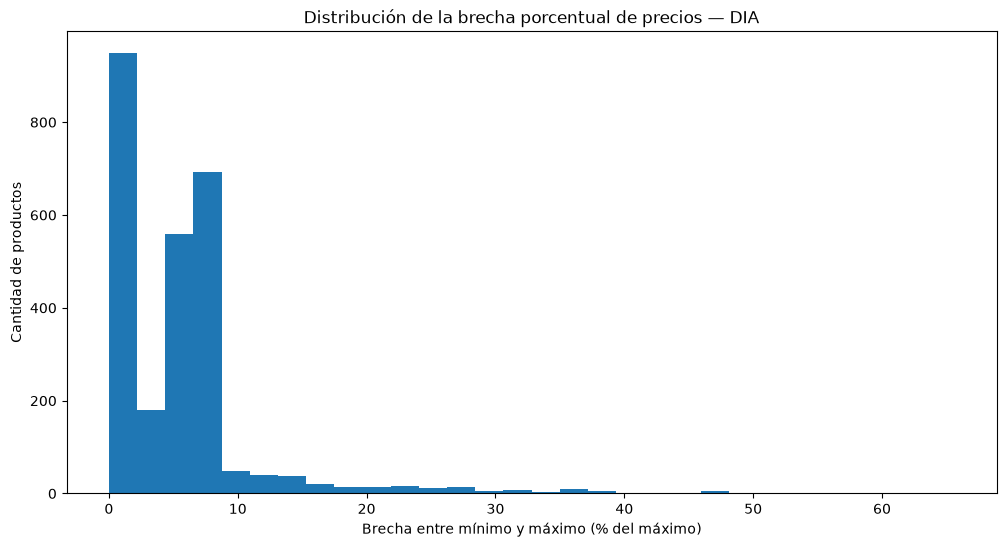

In [70]:
# La distribución se muestra con un histograma, que permite observar cómo
# se concentra la brecha porcentual y dónde aparecen los valores extremos.
plt.figure(figsize=(12, 6))
plt.hist(df_plot['rango_pct'].dropna(), bins=30)
plt.title('Distribución de la brecha porcentual de precios — DIA')
plt.xlabel('Brecha entre mínimo y máximo (% del máximo)')
plt.ylabel('Cantidad de productos')
plt.show()

In [71]:
# Identificamos los productos que superan los umbrales definidos para el análisis.
productos_superan_20 = (
    df_plot[df_plot['rango_pct'] > 20]
    .sort_values('rango_pct', ascending=False)
)

productos_superan_10_dia = df_plot[df_plot['rango_pct'] > 10]

n = productos_superan_10_dia.shape[0]
total = df_plot.shape[0]

print(
    f"Productos que superan el 10%: {n} de {total} "
    f"({n/total:.1%})"
)

print(
    f"Productos que superan el 20%: "
    f"{productos_superan_20.shape[0]} de {total} "
    f"({productos_superan_20.shape[0]/total:.1%})"
)

Productos que superan el 10%: 237 de 2646 (9.0%)
Productos que superan el 20%: 101 de 2646 (3.8%)


### Casos de alta dispersión

Los umbrales anteriores permiten identificar productos que merecen una inspección detallada. La existencia de una brecha elevada no implica por sí misma que exista una promoción generalizada: puede originarse por una observación puntual o por diferencias de precio de lista.

Por eso, los casos extremos se revisan directamente a nivel de producto y sucursal.

In [72]:
# Identificamos los casos con una brecha superior al 50%.
productos_superan_50 = (
    df_plot[df_plot['rango_pct'] > 50]
    .sort_values('rango_pct', ascending=False)
)

display(productos_superan_50.head(15))

,count,mean,std,min,25%,50%,75%,max,rango_pct
id_producto,,,,,,,,,
7790895012440,975.0,4877.933333,146.920688,1685.0,4900.0,4900.0,4900.0,4900.0,65.612245
7790895005794,975.0,2886.258462,1009.649899,2470.0,2496.0,2496.0,2496.0,5690.0,56.590510
7790895009815,975.0,1885.059487,611.712504,1532.0,1532.0,1532.0,2490.0,3250.0,52.861538
7790895648427,975.0,3157.005128,269.360210,1555.0,3200.0,3200.0,3200.0,3264.0,52.359069
7792798014019,975.0,2510.212308,598.597098,1420.0,2630.0,2840.0,2840.0,2897.0,50.983776


In [73]:
# Revisamos tres de los productos extremos identificados en el análisis exploratorio.
display(
    productos_dia_comunes[
        productos_dia_comunes['id_producto'] == "7790895012440"
    ]
)

display(
    productos_dia_comunes[
        productos_dia_comunes['id_producto'] == "7790895005794"
    ]
)

display(
    productos_dia_comunes[
        productos_dia_comunes['id_producto'] == "7790895009815"
    ]
)

,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2,precio_efectivo,contador_promos
1496,15,1,1,7790895012440,1,GASEO COLA LIGHT,1.75,LT,COCA,4900.0,2800.00,1.00,LT,NaN,NaN,NaN,NaN,4900.0,0
5803,15,1,3,7790895012440,1,GASEO COLA LIGHT,1.75,LT,COCA,4900.0,2800.00,1.00,LT,NaN,NaN,NaN,NaN,4900.0,0
10110,15,1,4,7790895012440,1,GASEO COLA LIGHT,1.75,LT,COCA,4900.0,2800.00,1.00,LT,NaN,NaN,NaN,NaN,4900.0,0
14417,15,1,5,7790895012440,1,GASEO COLA LIGHT,1.75,LT,COCA,4900.0,2800.00,1.00,LT,NaN,NaN,NaN,NaN,4900.0,0
18724,15,1,6,7790895012440,1,GASEO COLA LIGHT,1.75,LT,COCA,4900.0,2800.00,1.00,LT,NaN,NaN,NaN,NaN,4900.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4181840,15,1,8014,7790895012440,1,GASEO COLA LIGHT,1.75,LT,COCA,4290.0,2451.43,1.00,LT,NaN,NaN,NaN,NaN,4290.0,0
4186155,15,1,8016,7790895012440,1,GASEO COLA LIGHT,1.75,LT,COCA,4290.0,2451.43,1.00,LT,NaN,NaN,NaN,NaN,4290.0,0
4190468,15,1,8017,7790895012440,1,GASEO COLA LIGHT,1.75,LT,COCA,4290.0,2451.43,1.00,LT,NaN,NaN,NaN,NaN,4290.0,0
4194788,15,1,8018,7790895012440,1,GASEO COLA LIGHT,1.75,LT,COCA,4290.0,2451.43,1.00,LT,NaN,NaN,NaN,NaN,4290.0,0


,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2,precio_efectivo,contador_promos
1474,15,1,1,7790895005794,1,GASEO COLA,2.50,LT,COCA,2496.0,998.40,1.00,LT,NaN,NaN,1872.0,25% de descuento. 2DO AL 50% LINEA COC - Vigen...,2496.0,1
5781,15,1,3,7790895005794,1,GASEO COLA,2.50,LT,COCA,2496.0,998.40,1.00,LT,NaN,NaN,1872.0,25% de descuento. 2DO AL 50% LINEA COC - Vigen...,2496.0,1
10088,15,1,4,7790895005794,1,GASEO COLA,2.50,LT,COCA,2496.0,998.40,1.00,LT,NaN,NaN,1872.0,25% de descuento. 2DO AL 50% LINEA COC - Vigen...,2496.0,1
14395,15,1,5,7790895005794,1,GASEO COLA,2.50,LT,COCA,2496.0,998.40,1.00,LT,NaN,NaN,1872.0,25% de descuento. 2DO AL 50% LINEA COC - Vigen...,2496.0,1
18702,15,1,6,7790895005794,1,GASEO COLA,2.50,LT,COCA,2496.0,998.40,1.00,LT,NaN,NaN,1872.0,25% de descuento. 2DO AL 50% LINEA COC - Vigen...,2496.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4181818,15,1,8014,7790895005794,1,GASEO COLA,2.50,LT,COCA,2496.0,998.40,1.00,LT,NaN,NaN,1872.0,25% de descuento. 2DO AL 50% LINEA COC - Vigen...,2496.0,1
4186133,15,1,8016,7790895005794,1,GASEO COLA,2.50,LT,COCA,2856.0,1142.40,1.00,LT,NaN,NaN,2142.0,25% de descuento. 2DO AL 50% LINEA COC - Vigen...,2856.0,1
4190446,15,1,8017,7790895005794,1,GASEO COLA,2.50,LT,COCA,2496.0,998.40,1.00,LT,NaN,NaN,1872.0,25% de descuento. 2DO AL 50% LINEA COC - Vigen...,2496.0,1
4194766,15,1,8018,7790895005794,1,GASEO COLA,2.50,LT,COCA,2856.0,1142.40,1.00,LT,NaN,NaN,2142.0,25% de descuento. 2DO AL 50% LINEA COC - Vigen...,2856.0,1


,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2,precio_efectivo,contador_promos
1487,15,1,1,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,1532.0,1532.00,1.00,LT,NaN,NaN,1149.0,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,1532.0,1
5794,15,1,3,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,1532.0,1532.00,1.00,LT,NaN,NaN,1149.0,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,1532.0,1
10101,15,1,4,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,1532.0,1532.00,1.00,LT,NaN,NaN,1149.0,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,1532.0,1
14408,15,1,5,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,1532.0,1532.00,1.00,LT,NaN,NaN,1149.0,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,1532.0,1
18715,15,1,6,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,1532.0,1532.00,1.00,LT,NaN,NaN,1149.0,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,1532.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4181831,15,1,8014,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,2898.0,2898.00,1.00,LT,NaN,NaN,2173.5,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,2898.0,1
4186146,15,1,8016,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,2800.0,2800.00,1.00,LT,NaN,NaN,2100.0,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,2800.0,1
4190459,15,1,8017,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,2898.0,2898.00,1.00,LT,NaN,NaN,2173.5,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,2898.0,1
4194779,15,1,8018,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,2800.0,2800.00,1.00,LT,NaN,NaN,2100.0,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,2800.0,1


La inspección de estos casos permite distinguir entre una diferencia concentrada en una sucursal y una diferencia que se repite en varias sucursales. Esta revisión es necesaria porque una única observación extrema puede aumentar considerablemente el rango.

## 6. Coeficiente de variación — DIA

El rango identifica la distancia entre los valores mínimo y máximo, pero no describe cómo se distribuyen las observaciones entre ambos extremos.

Para complementar el análisis se calcula el **coeficiente de variación (CV)**.

El CV permite evaluar la dispersión relativa respecto del precio medio. Complementa al rango, aunque ambas métricas pueden verse afectadas por valores extremos.

In [74]:
# Calculamos el coeficiente de variación para cada producto.
describe_producto_dia['cv'] = (
    describe_producto_dia['std'] /
    describe_producto_dia['mean']
)

display(
    describe_producto_dia
    .sort_values('cv', ascending=False)
    .head(15)
)

,count,mean,std,min,25%,50%,75%,max,cv
id_producto,,,,,,,,,
7790895005794,975.0,2886.258462,1009.649899,2470.0,2496.0,2496.0,2496.0,5690.0,0.349813
7790895009815,975.0,1885.059487,611.712504,1532.0,1532.0,1532.0,2490.0,3250.0,0.324506
7790895001413,974.0,1597.281314,441.356159,1431.0,1431.0,1431.0,1431.0,2850.0,0.276317
7790895068096,975.0,3352.832821,832.283563,3036.0,3036.0,3036.0,3036.0,5690.0,0.248233
7790895646560,975.0,1717.449231,426.168177,1533.0,1533.0,1533.0,1533.0,2760.0,0.248140
7792798014019,975.0,2510.212308,598.597098,1420.0,2630.0,2840.0,2840.0,2897.0,0.238465
7792170110575,974.0,3309.834702,771.686215,2850.0,2850.0,2850.0,4450.0,5279.0,0.233149
7792170110568,974.0,3309.834702,771.686215,2850.0,2850.0,2850.0,4450.0,5279.0,0.233149
7792170110551,974.0,3309.834702,771.686215,2850.0,2850.0,2850.0,4450.0,5279.0,0.233149


In [75]:
# Inspeccionamos dos productos con CV elevado para determinar si la
# variabilidad está concentrada o distribuida entre sucursales.
# No inspeccionamos al primer producto de la lista porque ya lo revisamos
# en el análisis anterior.

display(
    productos_dia_comunes[
        productos_dia_comunes['id_producto'] == "7790895009815"
    ]
)

display(
    productos_dia_comunes[
        productos_dia_comunes['id_producto'] == "7790895001413"
    ]
)

,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2,precio_efectivo,contador_promos
1487,15,1,1,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,1532.0,1532.00,1.00,LT,NaN,NaN,1149.0,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,1532.0,1
5794,15,1,3,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,1532.0,1532.00,1.00,LT,NaN,NaN,1149.0,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,1532.0,1
10101,15,1,4,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,1532.0,1532.00,1.00,LT,NaN,NaN,1149.0,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,1532.0,1
14408,15,1,5,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,1532.0,1532.00,1.00,LT,NaN,NaN,1149.0,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,1532.0,1
18715,15,1,6,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,1532.0,1532.00,1.00,LT,NaN,NaN,1149.0,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,1532.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4181831,15,1,8014,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,2898.0,2898.00,1.00,LT,NaN,NaN,2173.5,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,2898.0,1
4186146,15,1,8016,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,2800.0,2800.00,1.00,LT,NaN,NaN,2100.0,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,2800.0,1
4190459,15,1,8017,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,2898.0,2898.00,1.00,LT,NaN,NaN,2173.5,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,2898.0,1
4194779,15,1,8018,7790895009815,1,JUGO SABOR NARANJA,1.00,LT,CEPIT,2800.0,2800.00,1.00,LT,NaN,NaN,2100.0,25% de descuento. 2DO AL 50% JUGO CEPI - Vigen...,2800.0,1


,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2,precio_efectivo,contador_promos
1464,15,1,1,7790895001413,1,GASEO COLA,1.00,LT,COCA,1431.0,1431.00,1.00,LT,NaN,NaN,NaN,NaN,1431.0,0
5771,15,1,3,7790895001413,1,GASEO COLA,1.00,LT,COCA,1431.0,1431.00,1.00,LT,NaN,NaN,NaN,NaN,1431.0,0
10078,15,1,4,7790895001413,1,GASEO COLA,1.00,LT,COCA,1431.0,1431.00,1.00,LT,NaN,NaN,NaN,NaN,1431.0,0
14385,15,1,5,7790895001413,1,GASEO COLA,1.00,LT,COCA,1431.0,1431.00,1.00,LT,NaN,NaN,NaN,NaN,1431.0,0
18692,15,1,6,7790895001413,1,GASEO COLA,1.00,LT,COCA,1431.0,1431.00,1.00,LT,NaN,NaN,NaN,NaN,1431.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4177495,15,1,8013,7790895001413,1,GASEO COLA,1.00,LT,COCA,1488.0,1488.00,1.00,LT,NaN,NaN,NaN,NaN,1488.0,0
4181808,15,1,8014,7790895001413,1,GASEO COLA,1.00,LT,COCA,1431.0,1431.00,1.00,LT,NaN,NaN,NaN,NaN,1431.0,0
4186123,15,1,8016,7790895001413,1,GASEO COLA,1.00,LT,COCA,1488.0,1488.00,1.00,LT,NaN,NaN,NaN,NaN,1488.0,0
4190436,15,1,8017,7790895001413,1,GASEO COLA,1.00,LT,COCA,1431.0,1431.00,1.00,LT,NaN,NaN,NaN,NaN,1431.0,0


El CV aporta una segunda perspectiva: un producto puede presentar un rango elevado por una única sucursal, mientras que otro puede mostrar una dispersión elevada porque varias sucursales se alejan del promedio.

Por lo tanto, rango y CV se utilizan como métricas complementarias y no como sustitutas.

# 7. Variabilidad de precios — Carrefour

Se replica el mismo procedimiento aplicado en DIA para que la comparación entre cadenas utilice idénticas métricas y umbrales.

In [76]:
# Eliminamos observaciones sin precio efectivo.
productos_carrefour_comunes = productos_carrefour_comunes.dropna(
    subset=['precio_efectivo']
).copy()

# Resumen estadístico del precio efectivo por producto.
describe_producto_carre = (
    productos_carrefour_comunes
    .groupby('id_producto')['precio_efectivo']
    .describe()
)

# Calculamos la misma brecha porcentual utilizada en DIA.
df_plot_carre = describe_producto_carre.copy()
df_plot_carre['rango_pct'] = (
    (df_plot_carre['max'] - df_plot_carre['min']) /
    df_plot_carre['max']
) * 100

df_plot_carre = df_plot_carre.sort_values('rango_pct')

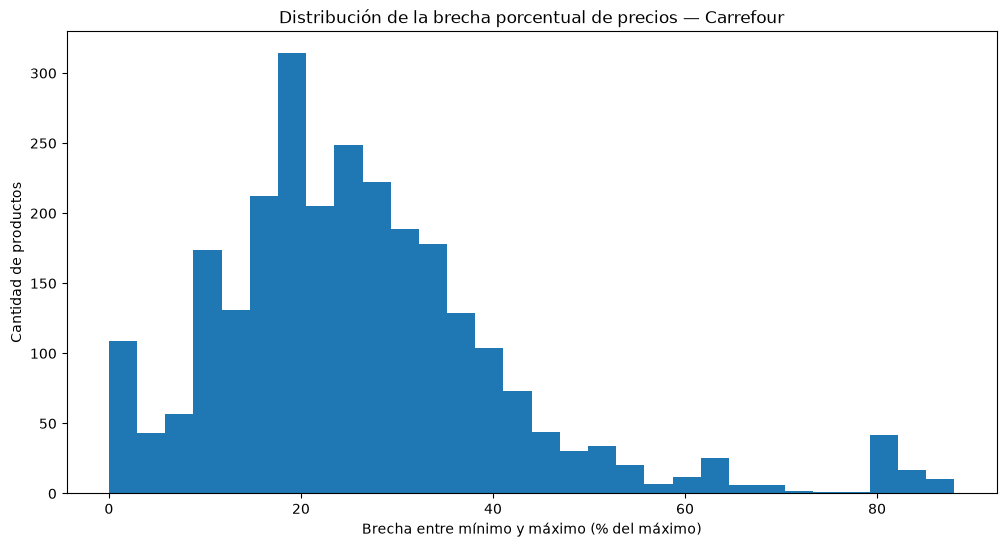

In [77]:
# Distribución de la brecha porcentual de precios en Carrefour.
plt.figure(figsize=(12, 6))
plt.hist(df_plot_carre['rango_pct'].dropna(), bins=30)
plt.title('Distribución de la brecha porcentual de precios — Carrefour')
plt.xlabel('Brecha entre mínimo y máximo (% del máximo)')
plt.ylabel('Cantidad de productos')
plt.show()

In [78]:
# Aplicamos los mismos umbrales utilizados en DIA.
productos_superan_10_carre = df_plot_carre[
    df_plot_carre['rango_pct'] > 10
]

n = productos_superan_10_carre.shape[0]
total = df_plot_carre.shape[0]

print(
    f"Productos que superan el 10%: {n} de {total} "
    f"({n/total:.1%})"
)

productos_superan_50 = (
    df_plot_carre[df_plot_carre['rango_pct'] > 50]
    .sort_values('rango_pct', ascending=False)
)

print(
    f"Productos que superan el 50%: "
    f"{productos_superan_50.shape[0]} de {total} "
    f"({productos_superan_50.shape[0]/total:.1%})"
)

Productos que superan el 10%: 2409 de 2646 (91.0%)
Productos que superan el 50%: 181 de 2646 (6.8%)


In [79]:
# Identificamos los productos que superan el 85% de brecha porcentual.
productos_superan_85 = (
    df_plot_carre[df_plot_carre['rango_pct'] > 85]
    .sort_values('rango_pct', ascending=False)
)
display(productos_superan_85)

,count,mean,std,min,25%,50%,75%,max,rango_pct
id_producto,,,,,,,,,
7790895006104,683.0,2741.963397,498.268124,490.0,2450.0,2450.0,3350.00,4100.0,88.048780
7793913013450,183.0,2135.907104,373.711305,323.0,2069.0,2250.0,2250.00,2400.0,86.541667
7791813434368,666.0,2065.659159,210.029363,340.0,2009.0,2159.0,2200.00,2500.0,86.400000
7791813888406,682.0,2049.195015,206.749393,340.0,1900.0,2159.0,2189.75,2500.0,86.400000
7791813444381,666.0,2053.244745,208.251103,330.0,1900.0,2159.0,2200.00,2399.0,86.244268
7793913013467,621.0,2279.140097,158.648896,331.0,2250.0,2319.0,2359.00,2400.0,86.208333
7792170052295,181.0,2713.337017,373.191569,500.0,2500.0,2750.0,3000.00,3600.0,86.111111
7790895064142,203.0,1864.192118,205.743803,358.0,1790.0,1790.0,1837.50,2550.0,85.960784
0000077976109,709.0,789.120310,81.255461,154.0,769.0,769.0,789.00,1060.0,85.471698


In [80]:
# Revisamos los casos extremos identificados en Carrefour.
display(
    productos_carrefour_comunes[
        productos_carrefour_comunes['id_producto'] == "7790895006104"
    ]
)

display(
    productos_carrefour_comunes[
        productos_carrefour_comunes['id_producto'] == "7793913013450"
    ]
)

,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2,precio_efectivo,contador_promos
5308,10,2,115,7790895006104,1,ISOTONICA FRUTAS TROPICALES POWERADE PET X 995 CC,1,UNI,POWERADE,2450.0,2462.31,995,CM3,NaN,NaN,NaN,NaN,2450.0,0
11279,10,2,205,7790895006104,1,ISOTONICA FRUTAS TROPICALES POWERADE PET X 995 CC,1,UNI,POWERADE,2450.0,2462.31,995,CM3,NaN,NaN,NaN,NaN,2450.0,0
15131,10,2,118,7790895006104,1,ISOTONICA FRUTAS TROPICALES POWERADE PET X 995 CC,1,UNI,POWERADE,2450.0,2462.31,995,CM3,NaN,NaN,NaN,NaN,2450.0,0
17456,10,3,492,7790895006104,1,ISOTONICA FRUTAS TROPICALES POWERADE PET X 995 CC,1,UNI,POWERADE,2450.0,2462.31,995,CM3,NaN,NaN,NaN,NaN,2450.0,0
19750,10,3,481,7790895006104,1,ISOTONICA FRUTAS TROPICALES POWERADE PET X 995 CC,1,UNI,POWERADE,2450.0,2462.31,995,CM3,NaN,NaN,NaN,NaN,2450.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3470021,10,1,10,7790895006104,1,ISOTONICA FRUTAS TROPICALES POWERADE PET X 995 CC,1,UNI,POWERADE,2450.0,2462.31,995,CM3,NaN,NaN,NaN,NaN,2450.0,0
3472473,10,3,556,7790895006104,1,ISOTONICA FRUTAS TROPICALES POWERADE PET X 995 CC,1,UNI,POWERADE,2450.0,2462.31,995,CM3,NaN,NaN,NaN,NaN,2450.0,0
3477684,10,3,766,7790895006104,1,ISOTONICA FRUTAS TROPICALES POWERADE PET X 995 CC,1,UNI,POWERADE,3520.0,3537.69,995,CM3,NaN,NaN,NaN,NaN,3520.0,0
3477947,10,3,606,7790895006104,1,ISOTONICA FRUTAS TROPICALES POWERADE PET X 995 CC,1,UNI,POWERADE,3520.0,3537.69,995,CM3,NaN,NaN,NaN,NaN,3520.0,0


,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2,precio_efectivo,contador_promos
20620,10,1,217,7793913013450,1,ARROZ CON LECHE CLASICO TREGAR POTE X 180 GRS,1,UNI,TREGAR,2250.0,12500.00,180,CM3,NaN,NaN,NaN,NaN,2250.0,0
54879,10,1,175,7793913013450,1,ARROZ CON LECHE CLASICO TREGAR POTE X 180 GRS,1,UNI,TREGAR,2300.0,12777.78,180,CM3,460.0,Promo A valida desde el 03/07/2026 hasta 04/07...,NaN,NaN,460.0,1
80717,10,4,503,7793913013450,1,ARROZ CON LECHE CLASICO TREGAR POTE X 180 GRS,1,UNI,TREGAR,2069.0,11494.44,180,CM3,NaN,NaN,NaN,NaN,2069.0,0
98665,10,4,507,7793913013450,1,ARROZ CON LECHE CLASICO TREGAR POTE X 180 GRS,1,UNI,TREGAR,2069.0,11494.44,180,CM3,NaN,NaN,NaN,NaN,2069.0,0
101214,10,1,123,7793913013450,1,ARROZ CON LECHE CLASICO TREGAR POTE X 180 GRS,1,UNI,TREGAR,2300.0,12777.78,180,CM3,NaN,NaN,NaN,NaN,2300.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3418917,10,2,141,7793913013450,1,ARROZ CON LECHE CLASICO TREGAR POTE X 180 GRS,1,UNI,TREGAR,2299.0,12772.22,180,CM3,NaN,NaN,NaN,NaN,2299.0,0
3423570,10,2,519,7793913013450,1,ARROZ CON LECHE CLASICO TREGAR POTE X 180 GRS,1,UNI,TREGAR,2250.0,12500.00,180,CM3,NaN,NaN,NaN,NaN,2250.0,0
3464187,10,2,510,7793913013450,1,ARROZ CON LECHE CLASICO TREGAR POTE X 180 GRS,1,UNI,TREGAR,2250.0,12500.00,180,CM3,NaN,NaN,NaN,NaN,2250.0,0
3475251,10,2,211,7793913013450,1,ARROZ CON LECHE CLASICO TREGAR POTE X 180 GRS,1,UNI,TREGAR,2250.0,12500.00,180,CM3,NaN,NaN,NaN,NaN,2250.0,0


La inspección de los casos extremos muestra que una brecha elevada puede concentrarse en una sola sucursal. Por ese motivo, antes de atribuir la dispersión a promociones generalizadas, es necesario analizar el comportamiento de la distribución completa mediante el coeficiente de variación y, posteriormente, separar el efecto del precio de lista del efecto promocional.

In [81]:
# Calculamos el coeficiente de variación para Carrefour.
describe_producto_carre['cv'] = (
    describe_producto_carre['std'] /
    describe_producto_carre['mean']
)

display(
    describe_producto_carre
    .sort_values('cv', ascending=False)
    .head(15)
)

,count,mean,std,min,25%,50%,75%,max,cv
id_producto,,,,,,,,,
7790250097648,183.0,2336.306011,718.391285,919.0,2040.0,2800.00,2800.00,2995.0,0.307490
7792170110551,178.0,3868.331461,1047.689876,2525.0,2850.0,4450.00,4825.00,5760.0,0.270838
7792170110704,694.0,3542.874640,921.199129,2525.0,2935.0,2989.00,4600.00,5760.0,0.260015
7790787030132,167.0,2787.874251,724.489494,515.0,2899.0,3029.00,3039.00,3500.0,0.259872
7792170110575,684.0,3542.248538,920.522930,2525.0,2935.0,2989.00,4600.00,5760.0,0.259870
7792170110568,688.0,3535.747093,918.214315,2525.0,2935.0,2989.00,4600.00,5760.0,0.259695
7792798015290,692.0,1151.254335,283.609547,990.0,990.0,990.00,1549.00,2050.0,0.246348
7891143018396,389.0,4469.974293,1054.898966,2990.0,2990.0,5235.00,5235.00,5640.0,0.235997
0000077907943,613.0,383.846656,90.207491,262.0,295.0,464.00,464.00,473.0,0.235009


In [82]:
# Inspeccionamos dos casos con CV elevado.
display(
    productos_carrefour_comunes[
        productos_carrefour_comunes['id_producto'] == "7790250097648"
    ]
)

display(
    productos_carrefour_comunes[
        productos_carrefour_comunes['id_producto'] == "7792170110551"
    ]
)

,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2,precio_efectivo,contador_promos
27861,10,4,505,7790250097648,1,TOALLA FEMENINA NORMAL SUAVE LADYSOFT X 8 UNI,1,UNI,LADYSOFT,919.0,114.88,8,UNI,NaN,NaN,NaN,NaN,919.0,0
74314,10,1,233,7790250097648,1,TOALLA FEMENINA NORMAL SUAVE LADYSOFT X 8 UNI,1,UNI,LADYSOFT,2040.0,255.00,8,UNI,NaN,NaN,NaN,NaN,2040.0,0
100345,10,2,181,7790250097648,1,TOALLA FEMENINA NORMAL SUAVE LADYSOFT X 8 UNI,1,UNI,LADYSOFT,2690.0,336.25,8,UNI,NaN,NaN,NaN,NaN,2690.0,0
216201,10,2,191,7790250097648,1,TOALLA FEMENINA NORMAL SUAVE LADYSOFT X 8 UNI,1,UNI,LADYSOFT,2349.0,293.62,8,UNI,NaN,NaN,NaN,NaN,2349.0,0
230507,10,1,149,7790250097648,1,TOALLA FEMENINA NORMAL SUAVE LADYSOFT X 8 UNI,1,UNI,LADYSOFT,2200.0,275.00,8,UNI,NaN,NaN,NaN,NaN,2200.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3402623,10,1,54,7790250097648,1,TOALLA FEMENINA NORMAL SUAVE LADYSOFT X 8 UNI,1,UNI,LADYSOFT,2799.0,349.88,8,UNI,NaN,NaN,NaN,NaN,2799.0,0
3435280,10,4,504,7790250097648,1,TOALLA FEMENINA NORMAL SUAVE LADYSOFT X 8 UNI,1,UNI,LADYSOFT,919.0,114.88,8,UNI,NaN,NaN,NaN,NaN,919.0,0
3439980,10,1,297,7790250097648,1,TOALLA FEMENINA NORMAL SUAVE LADYSOFT X 8 UNI,1,UNI,LADYSOFT,2800.0,350.00,8,UNI,NaN,NaN,NaN,NaN,2800.0,0
3441788,10,1,55,7790250097648,1,TOALLA FEMENINA NORMAL SUAVE LADYSOFT X 8 UNI,1,UNI,LADYSOFT,2799.0,349.88,8,UNI,NaN,NaN,NaN,NaN,2799.0,0


,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2,precio_efectivo,contador_promos
5477,10,2,511,7792170110551,1,ISOTONICA NARANJA GATORADE PET X 1.25 LT,1,UNI,GATORADE,2850.0,2280.00,1250,CM3,NaN,NaN,NaN,NaN,2850.0,0
19874,10,4,255,7792170110551,1,ISOTONICA NARANJA GATORADE PET X 1.25 LT,1,UNI,GATORADE,4450.0,3560.00,1250,CM3,NaN,NaN,NaN,NaN,4450.0,0
42995,10,1,297,7792170110551,1,ISOTONICA NARANJA GATORADE PET X 1.25 LT,1,UNI,GATORADE,2850.0,2280.00,1250,CM3,NaN,NaN,NaN,NaN,2850.0,0
53778,10,2,277,7792170110551,1,ISOTONICA NARANJA GATORADE PET X 1.25 LT,1,UNI,GATORADE,2850.0,2280.00,1250,CM3,NaN,NaN,NaN,NaN,2850.0,0
59821,10,2,137,7792170110551,1,ISOTONICA NARANJA GATORADE PET X 1.25 LT,1,UNI,GATORADE,4900.0,3920.00,1250,CM3,NaN,NaN,NaN,NaN,4900.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3417514,10,4,701,7792170110551,1,ISOTONICA NARANJA GATORADE PET X 1.25 LT,1,UNI,GATORADE,2525.0,2020.00,1250,CM3,NaN,NaN,NaN,NaN,2525.0,0
3419353,10,1,233,7792170110551,1,ISOTONICA NARANJA GATORADE PET X 1.25 LT,1,UNI,GATORADE,4450.0,3560.00,1250,CM3,NaN,NaN,NaN,NaN,4450.0,0
3451008,10,4,506,7792170110551,1,ISOTONICA NARANJA GATORADE PET X 1.25 LT,1,UNI,GATORADE,5450.0,4360.00,1250,CM3,NaN,NaN,NaN,NaN,5450.0,0
3458357,10,1,239,7792170110551,1,ISOTONICA NARANJA GATORADE PET X 1.25 LT,1,UNI,GATORADE,2850.0,2280.00,1250,CM3,NaN,NaN,NaN,NaN,2850.0,0


# 8. ¿La dispersión proviene de promociones o del precio de lista?

El rango y el coeficiente de variación miden **dispersión de precios en general**. Por sí solos no permiten determinar si la diferencia entre sucursales se debe a promociones.

Para investigar esta cuestión se compara la dispersión del `precio_efectivo` con la dispersión del **precio de lista**, sin incorporar promociones.

In [83]:
# Calculamos la dispersión del precio de lista por producto.
describe_lista_dia = (
    productos_dia_comunes
    .groupby('id_producto')['productos_precio_lista']
    .describe()
)

describe_lista_dia['rango_pct_lista'] = (
    (describe_lista_dia['max'] - describe_lista_dia['min']) /
    describe_lista_dia['max']
) * 100

describe_lista_carre = (
    productos_carrefour_comunes
    .groupby('id_producto')['productos_precio_lista']
    .describe()
)

describe_lista_carre['rango_pct_lista'] = (
    (describe_lista_carre['max'] - describe_lista_carre['min']) /
    describe_lista_carre['max']
) * 100

# Comparamos la dispersión total con la dispersión del precio de lista.
comparacion_dia = df_plot[['rango_pct']].join(
    describe_lista_dia[['rango_pct_lista']]
)

comparacion_carre = df_plot_carre[['rango_pct']].join(
    describe_lista_carre[['rango_pct_lista']]
)

print(
    "DIA — dispersión explicada solo por precio de lista (mediana):",
    comparacion_dia['rango_pct_lista'].median()
)
print(
    "DIA — dispersión total con efectivo (mediana):",
    comparacion_dia['rango_pct'].median()
)

print(
    "\nCarrefour — dispersión explicada solo por precio de lista (mediana):",
    comparacion_carre['rango_pct_lista'].median()
)
print(
    "Carrefour — dispersión total con efectivo (mediana):",
    comparacion_carre['rango_pct'].median()
)

DIA — dispersión explicada solo por precio de lista (mediana): 6.244640897021989
DIA — dispersión total con efectivo (mediana): 5.99095704596835

Carrefour — dispersión explicada solo por precio de lista (mediana): 22.25263198752024
Carrefour — dispersión total con efectivo (mediana): 24.51023603032128


Este contraste permite evaluar si la dispersión observada persiste incluso al excluir el efecto de las promociones.

Si el precio de lista ya presenta diferencias importantes entre sucursales, no sería correcto atribuir toda la heterogeneidad del precio efectivo a la estrategia promocional.

## 9. Profundidad del descuento

Para medir directamente el descuento se calcula la diferencia entre el precio de lista y el `precio_efectivo`.

En esta etapa, `precio_efectivo` incorpora el precio de lista y `promo1`; `promo2` permanece separada por tratarse de una promoción condicionada/especial.

In [84]:
# Calculamos el descuento porcentual respecto del precio de lista.
# El análisis posterior se restringe a observaciones con promo1.
productos_dia_comunes['descuento_pct'] = (
    (
        productos_dia_comunes['productos_precio_lista'] -
        productos_dia_comunes['precio_efectivo']
    )
    / productos_dia_comunes['productos_precio_lista']
) * 100

productos_carrefour_comunes['descuento_pct'] = (
    (
        productos_carrefour_comunes['productos_precio_lista'] -
        productos_carrefour_comunes['precio_efectivo']
    )
    / productos_carrefour_comunes['productos_precio_lista']
) * 100

In [85]:
# Resumimos la profundidad de los descuentos en las observaciones con promo1.
for nombre, df in [
    ('DIA', productos_dia_comunes),
    ('Carrefour', productos_carrefour_comunes)
]:
    con_promo = df[
        df['productos_precio_unitario_promo1'].notna()
    ]

    print(f"\n{nombre} — descuento_pct (observaciones con promo1):")
    print(con_promo['descuento_pct'].describe())


DIA — descuento_pct (observaciones con promo1):
count    267603.000000
mean         25.187256
std          10.837512
min           0.047973
25%          20.454545
50%          25.080732
75%          32.787891
max          62.060457
Name: descuento_pct, dtype: float64

Carrefour — descuento_pct (observaciones con promo1):
count    23540.000000
mean        15.929223
std         15.604701
min          0.002705
25%          2.057672
50%         12.618011
75%         25.131086
max         81.935484
Name: descuento_pct, dtype: float64


In [86]:
# Identificamos descuentos extremos para comparar su frecuencia.
umbral = 65

for nombre, df in [
    ('DIA', productos_dia_comunes),
    ('Carrefour', productos_carrefour_comunes)
]:
    con_promo = df[
        df['productos_precio_unitario_promo1'].notna()
    ]

    extremos = con_promo[
        con_promo['descuento_pct'] > umbral
    ]

    n = len(extremos)
    total = len(con_promo)

    print(
        f"{nombre}: {n} de {total} observaciones con "
        f"descuento >{umbral}% ({n/total:.1%})"
    )

DIA: 0 de 267603 observaciones con descuento >65% (0.0%)
Carrefour: 220 de 23540 observaciones con descuento >65% (0.9%)


## 10. Promociones condicionadas y generalización entre sucursales

`promo2` se mantiene como una variable independiente para evitar mezclar su comportamiento con el precio efectivo general (ver secciones 3 y 4). A continuación se verifica su presencia real en cada cadena y, luego, se analiza si las promociones que sí impactan en `precio_efectivo` (`promo1`) se aplican de forma puntual o generalizada entre sucursales.

In [87]:
# Revisamos la presencia de promo2 en los productos comunes de Carrefour.
display(
    productos_carrefour_comunes[
        productos_carrefour_comunes[
            'productos_precio_unitario_promo2'
        ].notna()
    ]
)

,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2,precio_efectivo,contador_promos,descuento_pct


In [88]:
# Revisamos la presencia de promo2 en los productos comunes de DIA.
display(
    productos_dia_comunes[
        productos_dia_comunes[
            'productos_precio_unitario_promo2'
        ].notna()
    ]
)

,id_comercio,id_bandera,id_sucursal,id_producto,productos_ean,productos_descripcion,productos_cantidad_presentacion,productos_unidad_medida_presentacion,productos_marca,productos_precio_lista,productos_precio_referencia,productos_cantidad_referencia,productos_unidad_medida_referencia,productos_precio_unitario_promo1,productos_leyenda_promo1,productos_precio_unitario_promo2,productos_leyenda_promo2,precio_efectivo,contador_promos,descuento_pct
9,15,1,1,0000077902320,1,ALFAJ RELL SAB MANI,30.00,GR,FULBI,375.0,12500.00,1.00,KG,NaN,NaN,250.00,33% de descuento. 3X2 ALF MANI FULBITO - Vigen...,375.0,1,0.000000
10,15,1,1,0000077903785,1,ALFAJOR TRIPLE MOUSS,55.00,GR,MILKA,2000.0,36363.64,1.00,KG,NaN,NaN,1333.33,33% de descuento. 3X2 ALF MILKA TERRAB - Vigen...,2000.0,1,0.000000
11,15,1,1,0000077903860,1,ALF TRIPLE CHOC TORT,70.00,GR,TERRA,2000.0,28571.43,1.00,KG,NaN,NaN,1333.33,33% de descuento. 3X2 ALFAJORES - Vigencia: De...,2000.0,1,0.000000
13,15,1,1,0000077908308,1,ALFAJOR SIMPLE,36.00,GR,TITA,1030.0,28611.11,1.00,KG,970.0,6% de descuento. Precio Promocional Exclusivo ...,750.00,21% de descuento. 2X$1500 ALFAJOR SIMP - Vigen...,970.0,2,5.825243
33,15,1,1,0000077988263,1,BANANITA,30.00,GR,DOLCA,1670.0,55666.67,1.00,KG,NaN,NaN,835.00,50% de descuento. 2X1 BANANITA DOLCA 3 - Vigen...,1670.0,1,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4199287,15,1,90000,8436581946154,1,DEO H COOL YOUR BODY,150.00,ML,REEBO,2460.0,16400.00,1.00,LT,NaN,NaN,1845.00,25% de descuento. 25% DEO REEBOK - Vigencia: D...,2460.0,1,0.000000
4199311,15,1,90000,8445291082199,1,CAFE DOLCA ORIGE FRS,100.00,GR,NESCA,9395.0,93950.00,1.00,KG,NaN,NaN,6106.75,35% de descuento. 35% NESCAFE DP FRASC - Vigen...,9395.0,1,0.000000
4199313,15,1,90000,8445291121904,1,CACAO POLVO S/PREMIX,800.00,GR,NESQU,12100.0,15125.00,1.00,KG,NaN,NaN,9075.00,25% de descuento. 2DO AL 50% CACAO NES - Vigen...,12100.0,1,0.000000
4199318,15,1,90000,8445291565425,1,CHOCO C/ALMENDRAS,25.00,GR,NESTL,1735.0,69400.00,1.00,KG,NaN,NaN,1150.00,34% de descuento. 2X$2300 CHOCOLATE NE - Vigen...,1735.0,1,0.000000


Confirmamos que Carrefour no registra un solo caso de `promo2` en los productos comunes analizados: no ofrece promociones condicionadas del tipo 2x1, 3x2 o descuentos por tarjeta dentro de este conjunto de datos. DIA, en cambio, sí utiliza este canal con frecuencia (15,7% de sus registros, según la sección 3). Esta diferencia estructural entre cadenas es relevante para interpretar correctamente las comparaciones de frecuencia de promoción que siguen.

In [89]:
# Identificamos los 15 productos con mayor descuento registrado en promo1
# y comparamos qué proporción de sus sucursales presenta esa promoción.

def obtener_top_promo1(df):
    # Nos quedamos únicamente con las observaciones que tienen promo1.
    con_promo1 = df[
        df['productos_precio_unitario_promo1'].notna()
        & df['productos_precio_lista'].notna()
        & (df['productos_precio_lista'] > 0)
    ].copy()

    # Calculamos el descuento correspondiente exclusivamente a promo1.
    con_promo1['descuento_promo1_pct'] = (
        (
            con_promo1['productos_precio_lista']
            - con_promo1['productos_precio_unitario_promo1']
        )
        / con_promo1['productos_precio_lista']
    ) * 100

    # Para cada producto tomamos el mayor descuento promo1 observado
    # entre sus sucursales.
    top_productos = (
        con_promo1
        .groupby('id_producto')['descuento_promo1_pct']
        .max()
        .sort_values(ascending=False)
        .head(15)
        .rename('descuento_promo1_pct')
    )

    return top_productos


# Obtenemos los 15 productos con mayor descuento promo1 de cada cadena.
top15_promo1_dia = obtener_top_promo1(productos_dia_comunes)
top15_promo1_carre = obtener_top_promo1(productos_carrefour_comunes)


# Calculamos la proporción de sucursales en las que cada producto
# registra promo1.
generalizacion_dia = (
    productos_dia_comunes
    .groupby('id_producto')['productos_precio_unitario_promo1']
    .apply(lambda x: x.notna().mean())
    .rename('frac_sucursales_con_promo')
)

generalizacion_carre = (
    productos_carrefour_comunes
    .groupby('id_producto')['productos_precio_unitario_promo1']
    .apply(lambda x: x.notna().mean())
    .rename('frac_sucursales_con_promo')
)


# Combinamos el descuento máximo de promo1 con su alcance entre sucursales.
top15_dia = (
    top15_promo1_dia
    .to_frame()
    .join(generalizacion_dia)
)

top15_carre = (
    top15_promo1_carre
    .to_frame()
    .join(generalizacion_carre)
)


# Mostramos los resultados ordenados de mayor a menor descuento.
with pd.option_context('display.float_format', '{:.2f}'.format):

    print("DIA - 15 productos con mayor descuento promo1:")
    display(top15_dia)

    print("Carrefour - 15 productos con mayor descuento promo1:")
    display(top15_carre)

DIA - 15 productos con mayor descuento promo1:


,descuento_promo1_pct,frac_sucursales_con_promo
id_producto,,
8436581946161,62.06,1.00
8436581946130,62.06,1.00
8436581946123,60.55,1.00
8436581946154,60.55,1.00
8445290883858,54.30,1.00
4005900773821,51.86,1.00
7891024112861,48.80,1.00
7891010560737,45.21,1.00
7798338291537,45.20,1.00


Carrefour - 15 productos con mayor descuento promo1:


,descuento_promo1_pct,frac_sucursales_con_promo
id_producto,,
7793147001025,81.94,0.00
7790787030132,81.45,0.10
7790895010088,81.30,0.00
7794820903094,80.86,0.01
7794820902806,80.79,0.01
7793913013467,80.76,0.00
7794000006898,80.58,0.07
7793913013993,80.57,0.03
7794820902721,80.47,0.02


Entre los productos de mayor dispersión, DIA muestra un patrón bimodal: la promoción está ausente en todas las sucursales o presente en absolutamente todas — no se observan casos intermedios. Carrefour, en cambio, nunca alcanza una promoción generalizada en estos casos: la fracción de sucursales con promo activa se mantiene por debajo del 10% incluso en sus productos de mayor dispersión. Esto refuerza la conclusión de la sección 8: en Carrefour, la alta dispersión de precios rara vez corresponde a una estrategia promocional extendida, sino a diferencias puntuales entre sucursales.

In [90]:
# Proporción de observaciones con al menos una promoción registrada, por cadena.
# Se mantiene esta métrica como resumen descriptivo del conjunto analizado.
prop_dia = (productos_dia_comunes['contador_promos'] > 0).mean()
prop_carrefour = (productos_carrefour_comunes['contador_promos'] > 0).mean()

print(f"DIA: {prop_dia:.1%} de las filas tienen alguna promoción registrada (promo1 + promo2)")
print(f"Carrefour: {prop_carrefour:.1%} de las filas tienen alguna promoción registrada (promo1 + promo2)")

# Comparación equivalente entre cadenas: solo promo1, ya que promo2 no
# se incorpora al precio efectivo y Carrefour no la utiliza (sección 3).
prop_dia_promo1 = productos_dia_comunes['productos_precio_unitario_promo1'].notna().mean()
prop_carre_promo1 = productos_carrefour_comunes['productos_precio_unitario_promo1'].notna().mean()

print(f"\nDIA — solo promo1 (comparación equivalente): {prop_dia_promo1:.1%}")
print(f"Carrefour — solo promo1: {prop_carre_promo1:.1%}")


DIA: 25.0% de las filas tienen alguna promoción registrada (promo1 + promo2)
Carrefour: 2.5% de las filas tienen alguna promoción registrada (promo1 + promo2)

DIA — solo promo1 (comparación equivalente): 10.5%
Carrefour — solo promo1: 2.5%


In [94]:
# ¿Cómo se distribuyen los productos de alta dispersión según la presencia
# de promo1 entre sucursales?
for nombre, datos in [('DIA', alta_dispersion_dia), ('Carrefour', alta_dispersion_carre)]:
    sin_promo = (datos['frac_sucursales_con_promo'] == 0).sum()
    generalizada = (datos['frac_sucursales_con_promo'] > 0.99).sum()
    intermedia = datos.shape[0] - sin_promo - generalizada
    print(f"{nombre}: {sin_promo} sin promo / {generalizada} generalizada / {intermedia} intermedia (de {datos.shape[0]})")

DIA: 8 sin promo / 9 generalizada / 0 intermedia (de 17)
Carrefour: 164 sin promo / 0 generalizada / 219 intermedia (de 383)


De los productos con **alta dispersión de precios** (`rango_pct` > 40%), Carrefour tiene muchos más casos que DIA — 383 contra 17 —, lo cual es consistente con su mayor dispersión general observada en la sección 7. Sin embargo, la composición de esos casos es muy distinta entre cadenas.

La salida de la celda anterior permite distinguir tres situaciones: ausencia de `promo1`, presencia de `promo1` en todas las sucursales y presencia en una fracción intermedia. Esta clasificación debe interpretarse exclusivamente dentro del universo de productos de alta dispersión y utilizando `promo1`, que es la promoción que impacta en `precio_efectivo`.

En DIA, los productos de alta dispersión muestran un patrón fuertemente concentrado en los extremos de la distribución de `frac_sucursales_con_promo`, mientras que en Carrefour predominan los casos en los que `promo1` aparece solo en una fracción de las sucursales. Esto sugiere que, dentro de este universo, la alta dispersión de Carrefour rara vez está asociada a una promoción extendida entre sucursales.

En síntesis, la presencia de `promo1` no se comporta de la misma manera en ambas cadenas. El análisis permite separar la dispersión de precios de la generalización de las promociones, evitando atribuir automáticamente una diferencia de precios a una política promocional extendida.

# 11. Conclusiones de esta etapa

## Principales hallazgos

### 1. Dispersión de precios

Carrefour presenta una mayor heterogeneidad de precios entre sucursales que DIA en el universo de productos comunes analizado. Esta diferencia debe interpretarse como **dispersión de precios**, no directamente como una estrategia comercial agresiva.

### 2. El rango no explica por sí solo el origen de la diferencia

Los casos extremos muestran que una brecha elevada puede estar concentrada en una única sucursal. El análisis de los productos de mayor dispersión (`rango_pct` > 40%, sección 10) permite además distinguir entre ausencia de `promo1`, presencia generalizada y presencia solo en una fracción de las sucursales. Dentro de este universo, el comportamiento es claramente diferente entre las cadenas: DIA concentra los casos en los extremos de la distribución de presencia de `promo1`, mientras que Carrefour presenta predominantemente presencia en una fracción de sus sucursales.

Esto sugiere que la mayor dispersión observada en Carrefour rara vez está asociada a una promoción extendida entre sucursales. Se trata de una asociación descriptiva dentro del universo analizado, no de una demostración de la estrategia comercial de la cadena.

### 3. Precio de lista y promociones representan fenómenos diferentes

La comparación entre la dispersión del precio efectivo y la del precio de lista (sección 8) muestra que parte de la heterogeneidad ya existe antes de considerar descuentos: en DIA, la dispersión del precio de lista (mediana 6,2%) es prácticamente igual a la del precio efectivo (5,99%), lo que indica que, a nivel de la mediana, la incorporación de promociones modifica poco la dispersión observada. En Carrefour, la dispersión de lista ya es alta por sí sola (22,3%) y la dispersión del precio efectivo alcanza 24,5%.

Por lo tanto, no es correcto atribuir automáticamente toda diferencia de precio entre sucursales a promociones.

### 4. Frecuencia y profundidad de las promociones

Es importante notar que las comparaciones de frecuencia son sensibles al canal considerado. Si se incluyen `promo1` y `promo2` combinados, DIA presenta actividad promocional en el 25,0% de sus registros frente al 2,5% de Carrefour. Pero como `promo2` no se incorpora al precio efectivo (secciones 3 y 4) ni Carrefour la utiliza dentro del universo analizado, la comparación equivalente es solo `promo1`: 10,5% en DIA frente a 2,5% en Carrefour — una diferencia real, aunque menor que la sugerida por la cifra combinada.

En cuanto a la profundidad del descuento (`descuento_pct`, sobre observaciones con `promo1`, sección 9), DIA descuenta en promedio más y de forma más consistente (media 25,2%, desvío 10,8) que Carrefour (media 15,9%, desvío 15,6, distribución mucho más heterogénea). Carrefour, sin embargo, concentra una mayor proporción de casos extremos: 0,9% de sus observaciones con promo1 superan el 65% de descuento, frente al 0,0% en DIA, que corresponde a 0 casos sobre 267.603 observaciones.

Por lo tanto, el término **"agresividad promocional"** depende de la dimensión considerada:

- en frecuencia y en profundidad típica del descuento, DIA presenta un comportamiento más marcado y más consistente;
- en presencia relativa de descuentos puntuales extremos, Carrefour presenta una mayor proporción, aunque estos casos son minoritarios dentro de sus observaciones con `promo1`.

### 5. Alcance de las conclusiones

Estos resultados describen exclusivamente las observaciones disponibles en los datasets de julio de 2026 y el universo de productos comunes entre ambas cadenas. No deben interpretarse automáticamente como una descripción permanente de la estrategia comercial de cada supermercado.

## 12. Limitaciones metodológicas de esta etapa

- La comparación se restringe a productos con `id_producto` presente en ambas cadenas.
- La dispersión puede estar influida por diferencias estructurales de precio de lista entre sucursales.
- `rango_pct` mide la brecha entre mínimo y máximo como porcentaje del máximo; no representa una variación porcentual respecto del mínimo.
- El coeficiente de variación complementa al rango, pero también puede verse afectado por valores extremos.
- `promo2` se mantiene separada del precio efectivo general por su carácter condicionado/especial.
- El análisis de generalización entre sucursales utiliza `promo1`, porque es la promoción incorporada al `precio_efectivo`.
- Las conclusiones se limitan al período y a los registros disponibles en los datasets analizados.

## 13. Cierre

Esta primera etapa permitió construir una base comparable entre DIA y Carrefour y establecer una distinción importante entre **dispersión de precios**, **presencia de promociones**, **generalización entre sucursales** y **profundidad del descuento**.

La principal conclusión hasta este punto es que una mayor dispersión de precios no implica necesariamente una mayor actividad promocional. Separar estos fenómenos permite interpretar con mayor precisión las diferencias observadas y deja una base metodológica clara para continuar el análisis en las siguientes etapas.